# CRYPTO ALTCOIN PROJECT

Bitcoin to Altcoin and Bitcoin to M2 compairsons

Can i use yfinance? we need to find M2 money supply data, altcoin data (binance? or yfinance?) bitcoin price can use yfinance 
use Granger test?

look into overalll comparision (all time)
look into cycles (ols seasonality as well)

bitcoin cycle (how to define the cycle? every 4 years is a gauge only) [https://charts.bitbo.io/cycle-repeat/]
altcoin cycle (altcoin index?)[https://coinmarketcap.com/charts/altcoin-season-index/]
how the corelate

money supply delayed effect to bitcoin prices.

future prices assumptions for altcoin as a whole and specific alt coins like fart, pop, etc✅
can look at sol and etherium as well✅

extra:
can look into altcoin average variance and sharpe ratio comparied to bitcoin

look at how sol and etherium returns compare to altcoins, do they affect each other in a waterfall effect as bitcoin pushes sol and etherium then pushed to alt coins?

look into US interest rates changes, when they come up, how they affect prices.

fear greed index

Regime Detection (Hidden Markov Models)

OLS Structue 
>PEPE_return(t+1) = β0

>                 + β1·BTC_return(t)

>                 + β2·ETH_return(t)

>                 + β3·meme_basket_return(t)

>                 + β4·PEPE_volume_zscore(t)

>                 + β5·funding_rate(t)

>                 + β6·OI_change(t)

>                 + β7·fear_greed(t)

>                 + β8·social_volume(t)

>                 + ε

Phase 1 — Data Collection
├── PEPE OHLCV (Binance API via CCXT)
├── BTC, ETH, DOGE, SHIB prices
├── Funding rates + Open Interest (Binance futures API)
└── Fear & Greed Index (alternative.me API — free)

Phase 2 — Factor Construction
├── Compute returns at your chosen frequency (1h recommended)
├── Lag all factors by 1 period
├── Z-score normalize
└── Check correlations, drop VIF > 10

Phase 3 — OLS Estimation
├── statsmodels OLS with Newey-West SEs
├── Rolling 30-day OLS to track beta stability
├── Walk-forward validation (no lookahead)
└── Check R², t-stats, residual diagnostics

Phase 4 — Signal to Strategy
├── Predicted return > threshold → long
├── Predicted return < -threshold → short
├── Size positions by signal strength
└── Backtest with transaction costs

https://blog.quantinsti.com/download-cryptocurrency-data-python-cryptocompare-api/

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib as mpl 
import matplotlib.pyplot as plt

# from lets_plot import * 
# LetsPlot.setup_html()

import datetime as dt 

In [ ]:
!pip install cryptocompare
import cryptocompare

In [ ]:
# Fetch the raw ticker list
raw_ticker_data = cryptocompare.get_coin_list()
# Convert the raw data from dictionary format to DataFrame
all_tickers = pd.DataFrame.from_dict(raw_ticker_data).T

def search_ticker(keyword):

    mask = all_tickers["FullName"].str.contains(keyword, case=False, na=False)
    results = all_tickers[mask].iloc[:,:8]
    return results

In [ ]:
# search_ticker("BTC")

> <mark>Now we get data. lets make a list of the Coins we want to find first
>
> CryptoCompare’s hourly API only gives you up to 2000 hours (~83 days) in one request. If you want BTC hourly data all the way back to 2020-01-01 → now, you’ll need to loop and stitch together multiple API calls.
>
> lets do daily data first, it will span past 2020

In [ ]:
coins_list = ["BTC", "SOL", "ETH", "WIF", "POPCAT", "GRASS", "FARTCOIN"]
                #ticker

In [ ]:
# Referance code to make to_datetime with time

# # If raw_price_data is a list of dicts (normal case)
# test2 = pd.DataFrame(testdata)

# # Convert "time" column to datetime
# test2['datetime'] = pd.to_datetime(test2['time'], unit='s')

# # Format as string (DD/MM/YYYY HH:MM)
# test2['datetime'] = test2['datetime'].dt.strftime('%d/%m/%Y %H:%M')

# # Set datetime as index (optional)
# test2.set_index('datetime', inplace=True)

# (test2.tail())

In [ ]:
def fetch_daily_prices(coins, currency="USD", limit=2000):
    """
    Fetch daily OHLCV data for multiple coins from CryptoCompare.
    Returns a dictionary of DataFrames.
    """
    data = {}
    for coin in coins:
        raw = cryptocompare.get_historical_price_day(
            coin=coin,
            currency=currency,
            limit=limit
        )
        if raw:
            df = pd.DataFrame(raw)
            df['Datetime'] = pd.to_datetime(df['time'], unit='s')
            df.set_index('Datetime', inplace=True)
            data[coin] = df
            print(f"Fetched {coin} ✅")
        else:
            print(f"⚠️ No data for {coin}")
    return data

# Usage
all_data = fetch_daily_prices(coins_list)


Fetched BTC ✅
Fetched SOL ✅
Fetched ETH ✅
Fetched WIF ✅
Fetched POPCAT ✅
Fetched GRASS ✅
Fetched FARTCOIN ✅


In [ ]:
coins=\
(
    pd
    .concat([df[['close']]
             .replace(0, np.nan)  
             .rename(columns={'close': coin}) 
             for coin, df in all_data.items()],
            axis=1
           )
)

close_prices.head()

,BTC,SOL,ETH,WIF,POPCAT,GRASS,FARTCOIN
Datetime,,,,,,,
2020-04-30,8637.56,0.6923,206.44,0.0,0.0,0.0,0.0
2020-05-01,8829.12,0.7244,212.16,0.0,0.0,0.0,0.0
2020-05-02,8981.11,0.7129,214.11,0.0,0.0,0.0,0.0
2020-05-03,8907.19,0.6820,210.12,0.0,0.0,0.0,0.0
2020-05-04,8881.65,0.6661,206.76,0.0,0.0,0.0,0.0


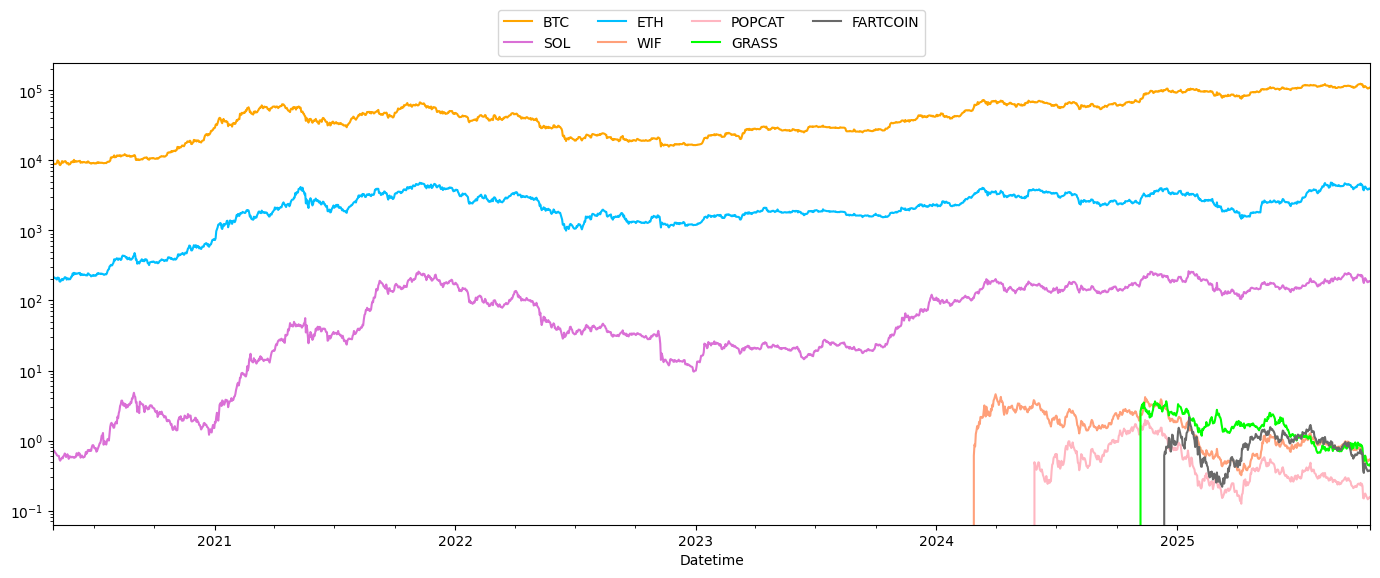

In [ ]:
(
    coins
    .plot(figsize=(17,6),
          logy=True,
          color = ("orange", "orchid", "deepskyblue","lightsalmon", "lightpink", "lime", "dimgrey")
         )
)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4)


In [ ]:
Stable = ["BTC", "SOL", "ETH"]
Alt = ["WIF", "POPCAT", "GRASS", "FARTCOIN"]

In [ ]:
coins.groupby(by = Stable,
                     axis = 0
                    ).head()

C:\Users\limji\AppData\Local\Temp\ipykernel_15400\937328090.py:1: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  coins.groupby(by = Stable,


,BTC,SOL,ETH,WIF,POPCAT,GRASS,FARTCOIN
Datetime,,,,,,,
2020-04-30,8637.56,0.6923,206.44,0.0000,0.0000,0.0000,0.0000
2020-05-01,8829.12,0.7244,212.16,0.0000,0.0000,0.0000,0.0000
2020-05-02,8981.11,0.7129,214.11,0.0000,0.0000,0.0000,0.0000
2020-05-03,8907.19,0.6820,210.12,0.0000,0.0000,0.0000,0.0000
2020-05-04,8881.65,0.6661,206.76,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...
2025-10-17,106485.41,182.0500,3833.18,0.5062,0.1449,0.4477,0.3640
2025-10-18,107228.76,187.6500,3890.70,0.5166,0.1489,0.4423,0.3673
2025-10-19,108701.79,187.9500,3984.90,0.5317,0.1539,0.4445,0.3746


In [ ]:
coins.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
BTC,2001.0,47842.9617,30076.8007,8568.8800,23959.6700,40811.0300,63614.0600,124723.000
SOL,2001.0,84.9877,74.4338,0.5156,20.5500,46.8500,148.9100,261.870
ETH,2001.0,2244.0534,1109.8989,185.7700,1579.0600,2140.4500,3093.6200,4830.600
WIF,603.0,1.6711,0.9781,0.3191,0.8256,1.5400,2.4835,4.585
POPCAT,511.0,0.5638,0.4116,0.1252,0.2706,0.3963,0.7279,1.964
GRASS,350.0,1.6558,0.7654,0.4368,0.9425,1.6120,2.1908,3.642
FARTCOIN,314.0,0.8854,0.3627,0.2184,0.6050,0.9068,1.1418,2.159


> Lets look at correlation between the altcoins to  BTC & SOL

> find other economic data points.
> USD money supply(timeseries comparision),
> TBill(risk free rates)(correlation),
> interest rate announcment dates(time series)